In [1]:
from stable_baselines3.dqn import MlpPolicy

from Simulation.DRL_implementations.Masked_DQN import MaskedDoubleDQN
%load_ext autoreload
%autoreload 2

### Global Variables
DATA_SAVE_PATH = "../../../models/used_data"
DAYS_PER_EPISODE = 3
TRAIN_TEST_SPLIT_FRACTION = 0.2  # Amount of data you reserve for testing.
BUFFER_DAYS = 3  # Amount of days that needs to be between the test episodes.

In [2]:
from Simulation.suite_simple_trading.pre_processing import clean_data
import pandas as pd
import os
from Simulation.suite_simple_trading.data_splitting import get

### Getting data

raw_data_path = '../../../data/2025_minute.csv'
cleaned_data_cache_path = '../../../data/2025_minute_cleaned.pkl'

if os.path.exists(cleaned_data_cache_path):
    print(f"Loading cached cleaned data from: {cleaned_data_cache_path}")
    cleaned_df = pd.read_pickle(cleaned_data_cache_path)
else:
    print("No cached data found. Running the full cleaning process...")
    raw_df = pd.read_csv(raw_data_path, sep=';')
    cleaned_df = clean_data(raw_df)
    print(f"Saving cleaned data to cache: {cleaned_data_cache_path}")
    cleaned_df.to_pickle(cleaned_data_cache_path)

all_data = cleaned_df[['Datetime', 'Imbalance Price']]
train_df, test_df, val_df, nr_of_episodes = get_or_create_train_val_test_split(
    all_data=all_data,
    save_path=DATA_SAVE_PATH,
    days_per_episode=DAYS_PER_EPISODE,
    test_fraction=TRAIN_TEST_SPLIT_FRACTION,
    val_fraction=
    buffer_days=BUFFER_DAYS
)


Loading cached cleaned data from: ../../../data/2025_minute_cleaned.pkl
--- Loading existing train/test data from '../../../models/used_data' ---
--- Data loaded successfully. Found 19 test episodes. ---
Test Data Size / Train Data Size: 0.25


In [8]:
from stable_baselines3 import DQN
from Simulation.suite_simple_trading.observation_wrappers import RobustScalingWrapper, SoCPenaltyWrapper

### The model (Environment) used in all agents
from Simulation.suite_simple_trading.model import ExtendedBatteryEnv

train_env_dqn = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_scaled_obs = RobustScalingWrapper(train_env_dqn)
dqn_agent = DQN("MlpPolicy", train_env_scaled_obs)
dqn_agent.learn(1_000_000)


--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


In [9]:
from Simulation.suite_simple_trading.simulation import run_evaluation

test_env_dqn = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)
test_env_scaled_obs = RobustScalingWrapper(test_env_dqn)
test_env_scaled_obs_SoC_pen = SoCPenaltyWrapper(test_env_scaled_obs)
result_dqn = run_evaluation(test_env_scaled_obs_SoC_pen, dqn_agent, number_of_episodes=nr_of_episodes, is_masked=False)

print(f"reward ppo: {sum(result_dqn["real_rewards"])}")
result_dqn.pop("episodic_rewards")
history_df = pd.DataFrame(result_dqn)
history_df['Datetime'] = test_df['Datetime']

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: 2161.29
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: -3245.94
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: -51.81
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: -3272.14
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: -3396.82
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: 4695.98
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished with tota

Saving plot to: plots/test_reward_shaping


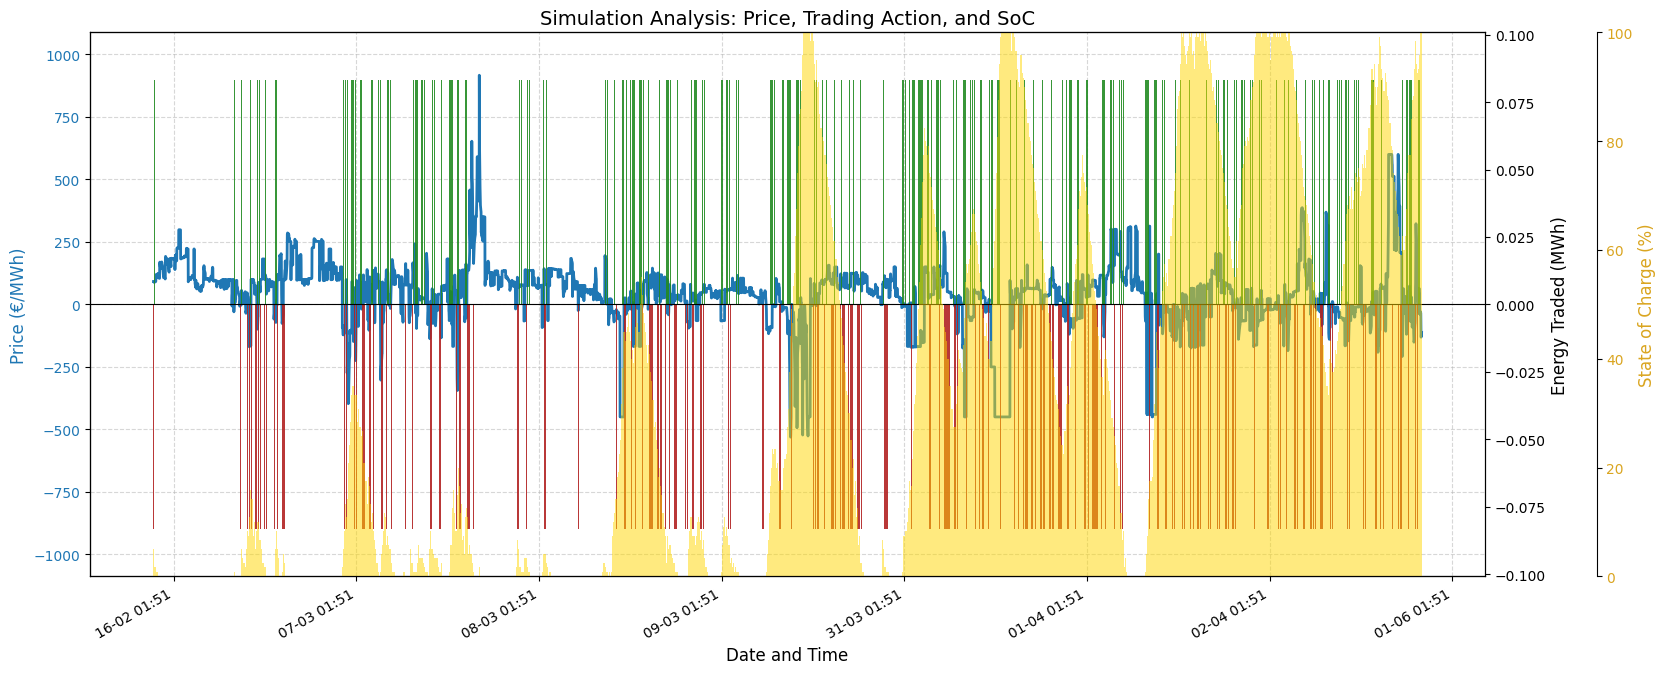

In [15]:
from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute, plot_feature_importance

plot_simulation_results_minute_by_minute(
    history_df,
    "test_reward_shaping",
    20_000,
    30_000,
    10
)

Saving plot to: plots/test_reward_shaping


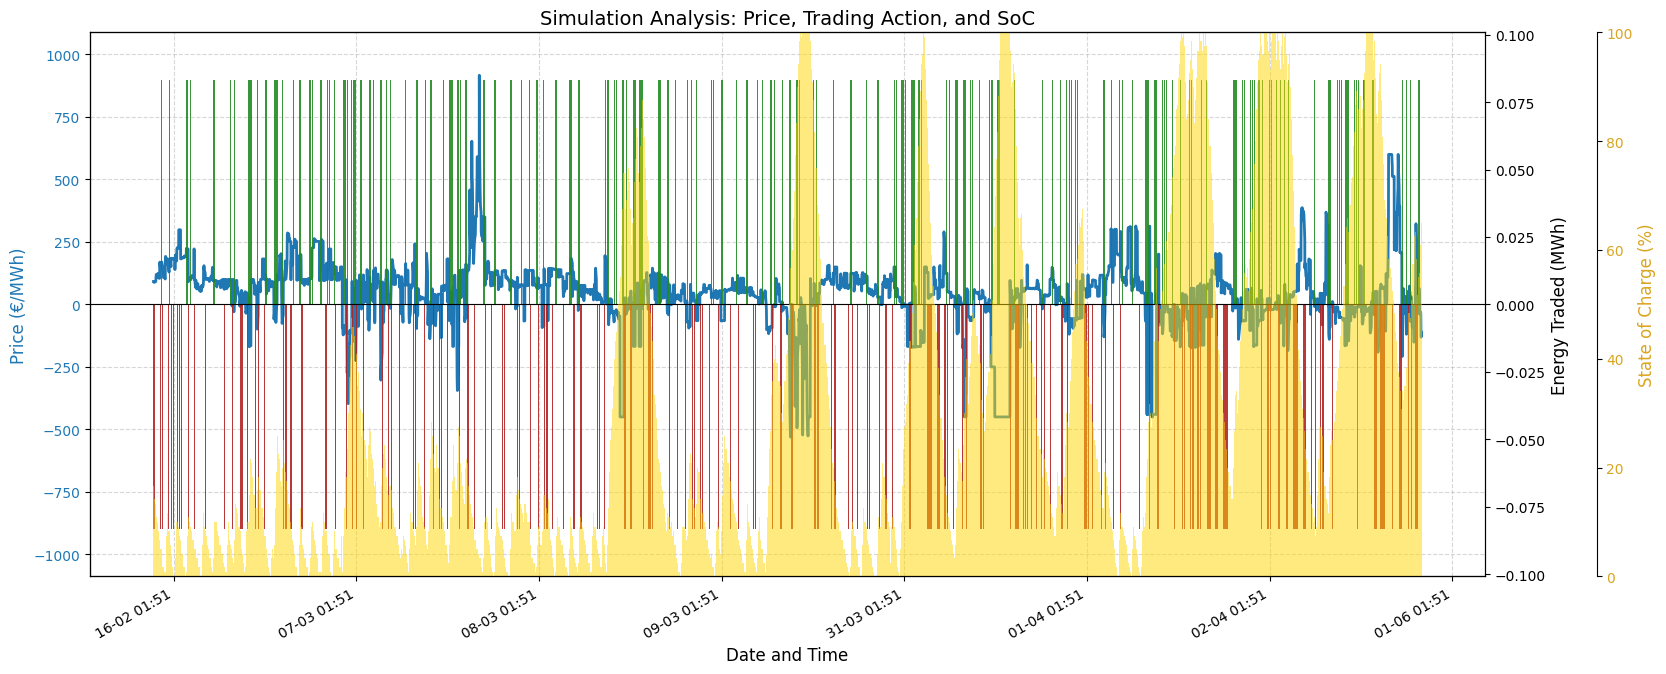

In [10]:
from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute, plot_feature_importance

plot_simulation_results_minute_by_minute(
    history_df,
    "test_reward_shaping",
    20_000,
    30_000,
    10
)

In [16]:
from Simulation.suite_simple_trading.metrics import print_agent_performance
print_agent_performance(history_df, "PPO Agent Compare")

  PERFORMANCE REPORT: PPO Agent Compare
  Pos. Profit Quarters : 127
  Neg. Profit Quarters : 18
----------------------------------------
  Success Rate (Active): 87.59%
  Mean Reward / active Quarter: €40.4373
----------------------------------------
  'Trap' Quarters      : 5
  (Started good -> Ended bad)



In [11]:
from Simulation.suite_simple_trading.metrics import print_agent_performance

print_agent_performance(history_df, "DQN Agent Compare")

  PERFORMANCE REPORT: DQN Agent Compare
  Pos. Profit Quarters : 383
  Neg. Profit Quarters : 75
----------------------------------------
  Success Rate (Active): 83.62%
  Mean Reward / active Quarter: €13.5158
----------------------------------------
  'Trap' Quarters      : 6
  (Started good -> Ended bad)

